Veri yüklenirken hata oluştu: [Errno 2] No such file or directory: 'data.csv'
Lütfen 'data.csv' dosyasını kontrol edin.


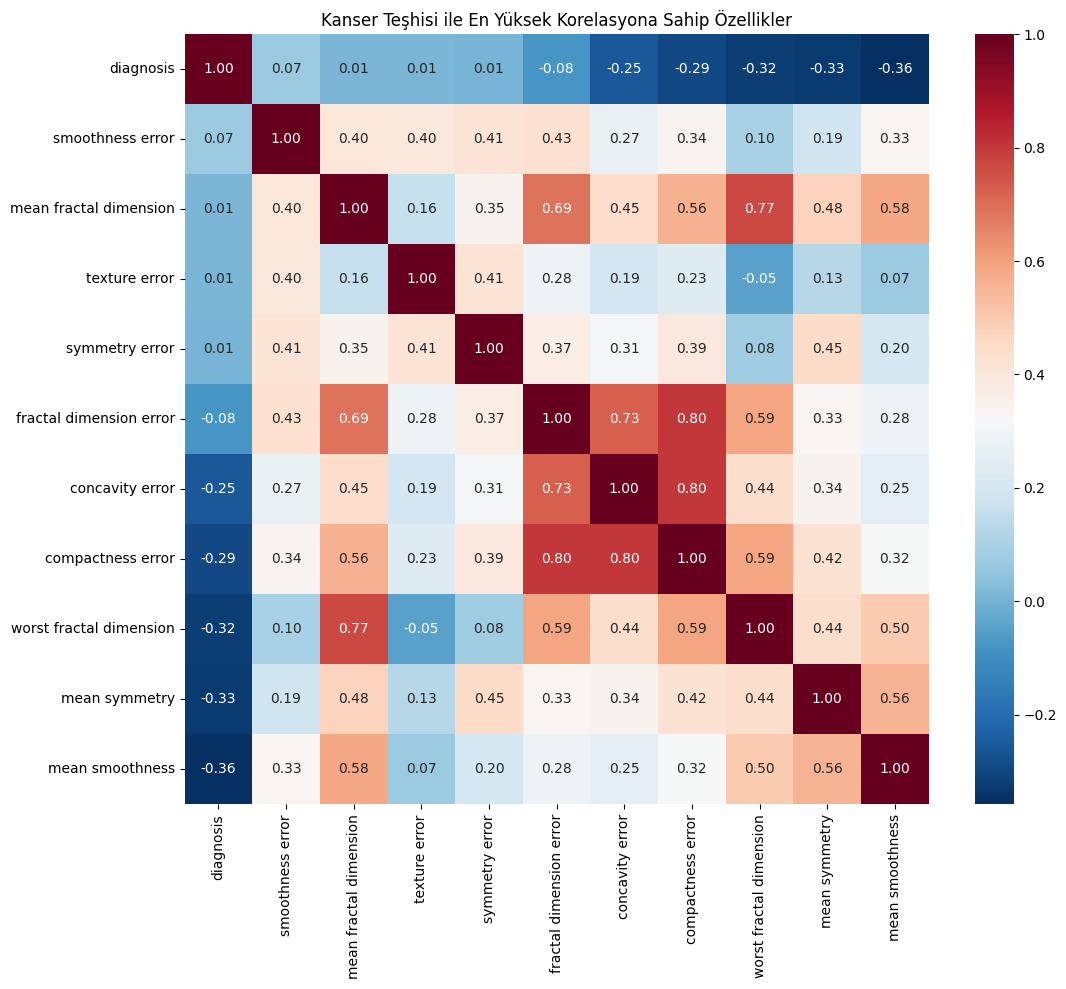


--- Random Forest Performans Raporu ---
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114


--- Logistic Regression Performans Raporu ---
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



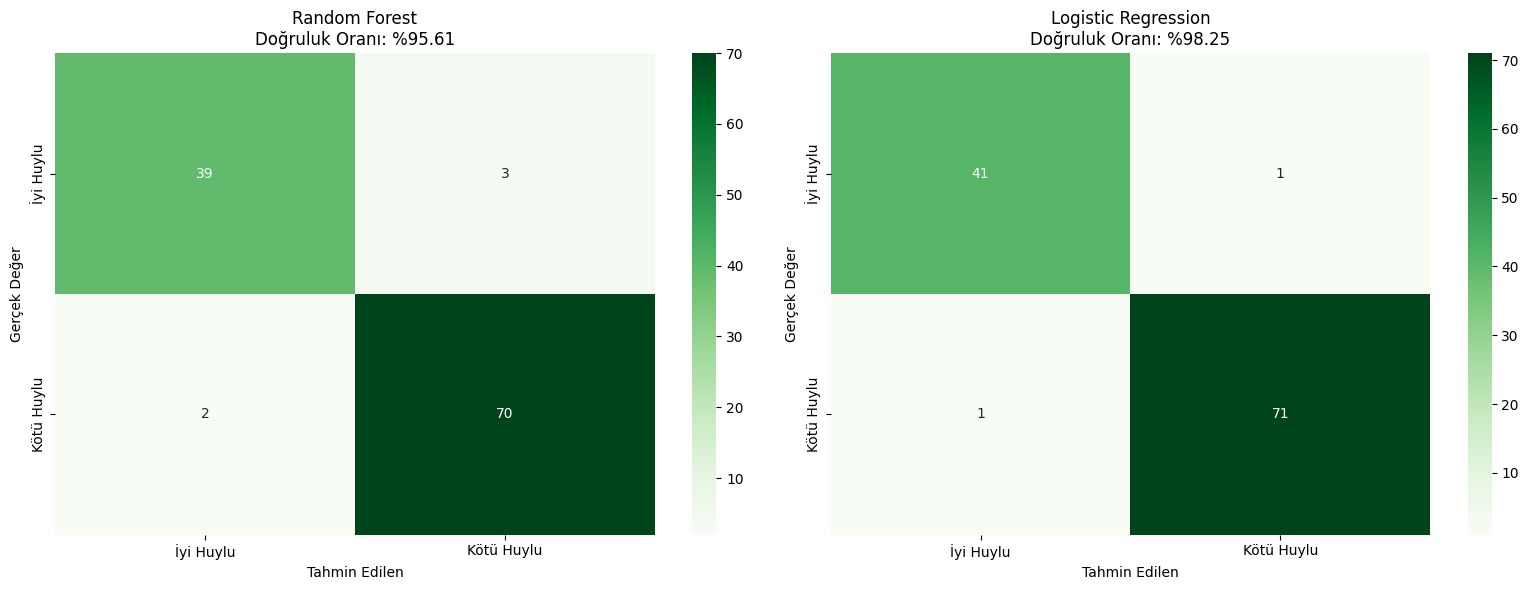

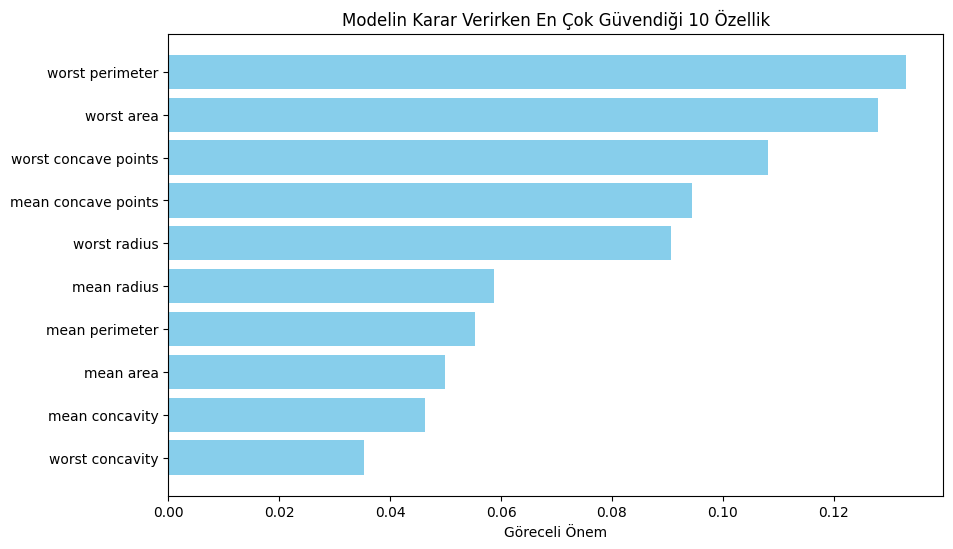


🚀 İşlem tamamlandı! GitHub reponuz için hazır.


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Makine Öğrenmesi Kütüphaneleri
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# ==========================================
# 1. VERİ YÜKLEME VE ÖN İŞLEME
# ==========================================
# Not: 'data.csv' dosyanızın aynı klasörde olduğundan emin olun.
try:
    df = pd.read_csv('data.csv')
    # Gereksiz sütunları (id ve boş sütunlar) temizle
    df = df.drop(columns=[col for col in df.columns if "id" in col.lower() or "unnamed" in col.lower()])
    # Hedef değişkeni sayısal yap (M=1, B=0)
    if 'diagnosis' in df.columns:
        df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})
except Exception as e:
    print(f"Veri yüklenirken hata oluştu: {e}")
    print("Lütfen 'data.csv' dosyasını kontrol edin.")

# ==========================================
# 2. EDA VE KORELASYON ANALİZİ
# ==========================================
# Korelasyon Isı Haritası
plt.figure(figsize=(12, 10))
correlation_matrix = df.corr()
# Sadece teşhis ile en çok ilgili olan ilk 10 özelliği görselleştirelim
top_features = correlation_matrix['diagnosis'].sort_values(ascending=False).head(11).index
sns.heatmap(df[top_features].corr(), annot=True, cmap='RdBu_r', fmt='.2f')
plt.title("Kanser Teşhisi ile En Yüksek Korelasyona Sahip Özellikler")
plt.show()

# ==========================================
# 3. VERİ AYIRMA (80/20) VE ÖLÇEKLENDİRME
# ==========================================
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

# Ödev gereksinimi: %80 Eğitim, %20 Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Modellerin kararlı çalışması için standartlaştırma
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# 4. MODEL EĞİTİMİ VE KARŞILAŞTIRMA
# ==========================================
models = {
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000)
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    results[name] = {
        "acc": accuracy_score(y_test, y_pred),
        "cm": confusion_matrix(y_test, y_pred),
        "report": classification_report(y_test, y_pred),
        "model_obj": model
    }

# ==========================================
# 5. SONUÇLARIN GÖRSELLEŞTİRİLMESİ
# ==========================================
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

for i, (name, res) in enumerate(results.items()):
    # Confusion Matrix Çizimi
    sns.heatmap(res['cm'], annot=True, fmt='d', cmap='Greens', ax=ax[i],
                xticklabels=['İyi Huylu', 'Kötü Huylu'],
                yticklabels=['İyi Huylu', 'Kötü Huylu'])
    ax[i].set_title(f"{name}\nDoğruluk Oranı: %{res['acc']*100:.2f}")
    ax[i].set_xlabel("Tahmin Edilen")
    ax[i].set_ylabel("Gerçek Değer")

    print(f"\n--- {name} Performans Raporu ---")
    print(res['report'])

plt.tight_layout()
plt.show()

# ==========================================
# 6. ÖZELLİK ÖNEM SIRALAMASI (Random Forest için)
# ==========================================
rf_model = results["Random Forest"]["model_obj"]
importances = rf_model.feature_importances_
indices = np.argsort(importances)[-10:] # En önemli 10 özellik

plt.figure(figsize=(10, 6))
plt.title("Modelin Karar Verirken En Çok Güvendiği 10 Özellik")
plt.barh(range(len(indices)), importances[indices], color='skyblue', align='center')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel('Göreceli Önem')
plt.show()

print("\n🚀 İşlem tamamlandı! GitHub reponuz için hazır.")